# ETAPA 2 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
## Predição de Doença Cardiovascular

**Dataset:** Cardiovascular Disease Dataset (Kaggle)  
**Objetivo:** Explorar a estrutura, distribuições, correlações e qualidade dos dados para preparar modelagem.

---

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("✓ Bibliotecas carregadas com sucesso")

✓ Bibliotecas carregadas com sucesso


## 2. Carregamento do Dataset

In [2]:
# Carregar o dataset (ajuste o caminho se necessário)
df = pd.read_csv('../src/cardio_train.csv', sep=';')
print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dataset carregado com sucesso!
Dimensões: 70,000 linhas × 13 colunas


## 3. Inspeção Estrutural

In [3]:
print("PRIMEIRAS 5 LINHAS:")
display(df.head())

print("\nÚLTIMAS 5 LINHAS:")
display(df.tail())

PRIMEIRAS 5 LINHAS:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



ÚLTIMAS 5 LINHAS:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [4]:
# Informações estruturais
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
display(info_df)

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

,Tipo,Nulos,Nulos (%),Únicos
id,int64,0,0.0,70000
age,int64,0,0.0,8076
gender,int64,0,0.0,2
height,int64,0,0.0,109
weight,float64,0,0.0,287
ap_hi,int64,0,0.0,153
ap_lo,int64,0,0.0,157
cholesterol,int64,0,0.0,3
gluc,int64,0,0.0,3
smoke,int64,0,0.0,2



Registros duplicados: 0


## 4. Preparação das Variáveis

In [5]:
# Criar cópia de trabalho com idade em anos
df_plot = df.copy()
df_plot['age_years'] = (df_plot['age'] / 365.25).round(1)

# Mapeamentos para legibilidade nos gráficos
df_plot['gender_label'] = df_plot['gender'].map({1: 'Feminino', 2: 'Masculino'})
df_plot['cardio_label'] = df_plot['cardio'].map({0: 'Sem doença', 1: 'Com doença'})
df_plot['cholesterol_label'] = df_plot['cholesterol'].map({
    1: 'Normal', 2: 'Acima do normal', 3: 'Muito acima'})
df_plot['gluc_label'] = df_plot['gluc'].map({
    1: 'Normal', 2: 'Acima do normal', 3: 'Muito acima'})

# IMC calculado
df_plot['bmi'] = (df_plot['weight'] / ((df_plot['height'] / 100) ** 2)).round(2)

print("✓ Variáveis de apoio criadas")

✓ Variáveis de apoio criadas


## 5. Estatísticas Descritivas

In [6]:
# Variáveis numéricas para análise descritiva
df_desc = df_plot[['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']].copy()
df_desc.columns = ['Idade (anos)', 'Altura (cm)', 'Peso (kg)',
                   'Pressão Sistólica', 'Pressão Diastólica', 'IMC']

desc = df_desc.describe().T
desc['mediana'] = df_desc.median()
desc['moda'] = df_desc.mode().iloc[0]
desc['IQR'] = df_desc.quantile(0.75) - df_desc.quantile(0.25)
desc['assimetria'] = df_desc.skew()
desc['curtose'] = df_desc.kurtosis()

cols_print = ['count', 'mean', 'mediana', 'moda', 'std', 'IQR',
              'min', '25%', '75%', 'max', 'assimetria', 'curtose']
desc_final = desc[cols_print].round(2)
desc_final.index.name = 'Variável'

display(desc_final)

,count,mean,mediana,moda,std,IQR,min,25%,75%,max,assimetria,curtose
Variável,,,,,,,,,,,,
Idade (anos),70000.0,53.30,53.90,56.00,6.76,10.00,29.60,48.40,58.40,64.90,-0.31,-0.82
Altura (cm),70000.0,164.36,165.00,165.00,8.21,11.00,55.00,159.00,170.00,250.00,-0.64,7.94
Peso (kg),70000.0,74.21,72.00,65.00,14.40,17.00,10.00,65.00,82.00,200.00,1.01,2.59
Pressão Sistólica,70000.0,128.82,120.00,120.00,154.01,20.00,-150.00,120.00,140.00,16020.00,85.30,7580.07
Pressão Diastólica,70000.0,96.63,80.00,80.00,188.47,10.00,-70.00,80.00,90.00,11000.00,32.11,1425.91
IMC,70000.0,27.56,26.38,23.88,6.09,6.34,3.47,23.88,30.22,298.67,7.73,221.23


In [7]:
# Variáveis categóricas
print("DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS:\n")
cat_vars = {
    'Gênero': df_plot['gender_label'],
    'Colesterol': df_plot['cholesterol_label'],
    'Glicose': df_plot['gluc_label'],
    'Tabagismo': df_plot['smoke'],
    'Álcool': df_plot['alco'],
    'Atividade física': df_plot['active'],
    'Doença cardiovascular': df_plot['cardio_label']
}

for nome, serie in cat_vars.items():
    vc = serie.value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(f"\n{nome}:")
    for val in vc.index:
        print(f"  {val}: {vc[val]:,} ({pct[val]}%)")

DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS:


Gênero:
  Feminino: 45,530 (65.0%)
  Masculino: 24,470 (35.0%)

Colesterol:
  Normal: 52,385 (74.8%)
  Acima do normal: 9,549 (13.6%)
  Muito acima: 8,066 (11.5%)

Glicose:
  Normal: 59,479 (85.0%)
  Muito acima: 5,331 (7.6%)
  Acima do normal: 5,190 (7.4%)

Tabagismo:
  0: 63,831 (91.2%)
  1: 6,169 (8.8%)

Álcool:
  0: 66,236 (94.6%)
  1: 3,764 (5.4%)

Atividade física:
  1: 56,261 (80.4%)
  0: 13,739 (19.6%)

Doença cardiovascular:
  Sem doença: 35,021 (50.0%)
  Com doença: 34,979 (50.0%)


## 6. Distribuições - Histogramas e KDE

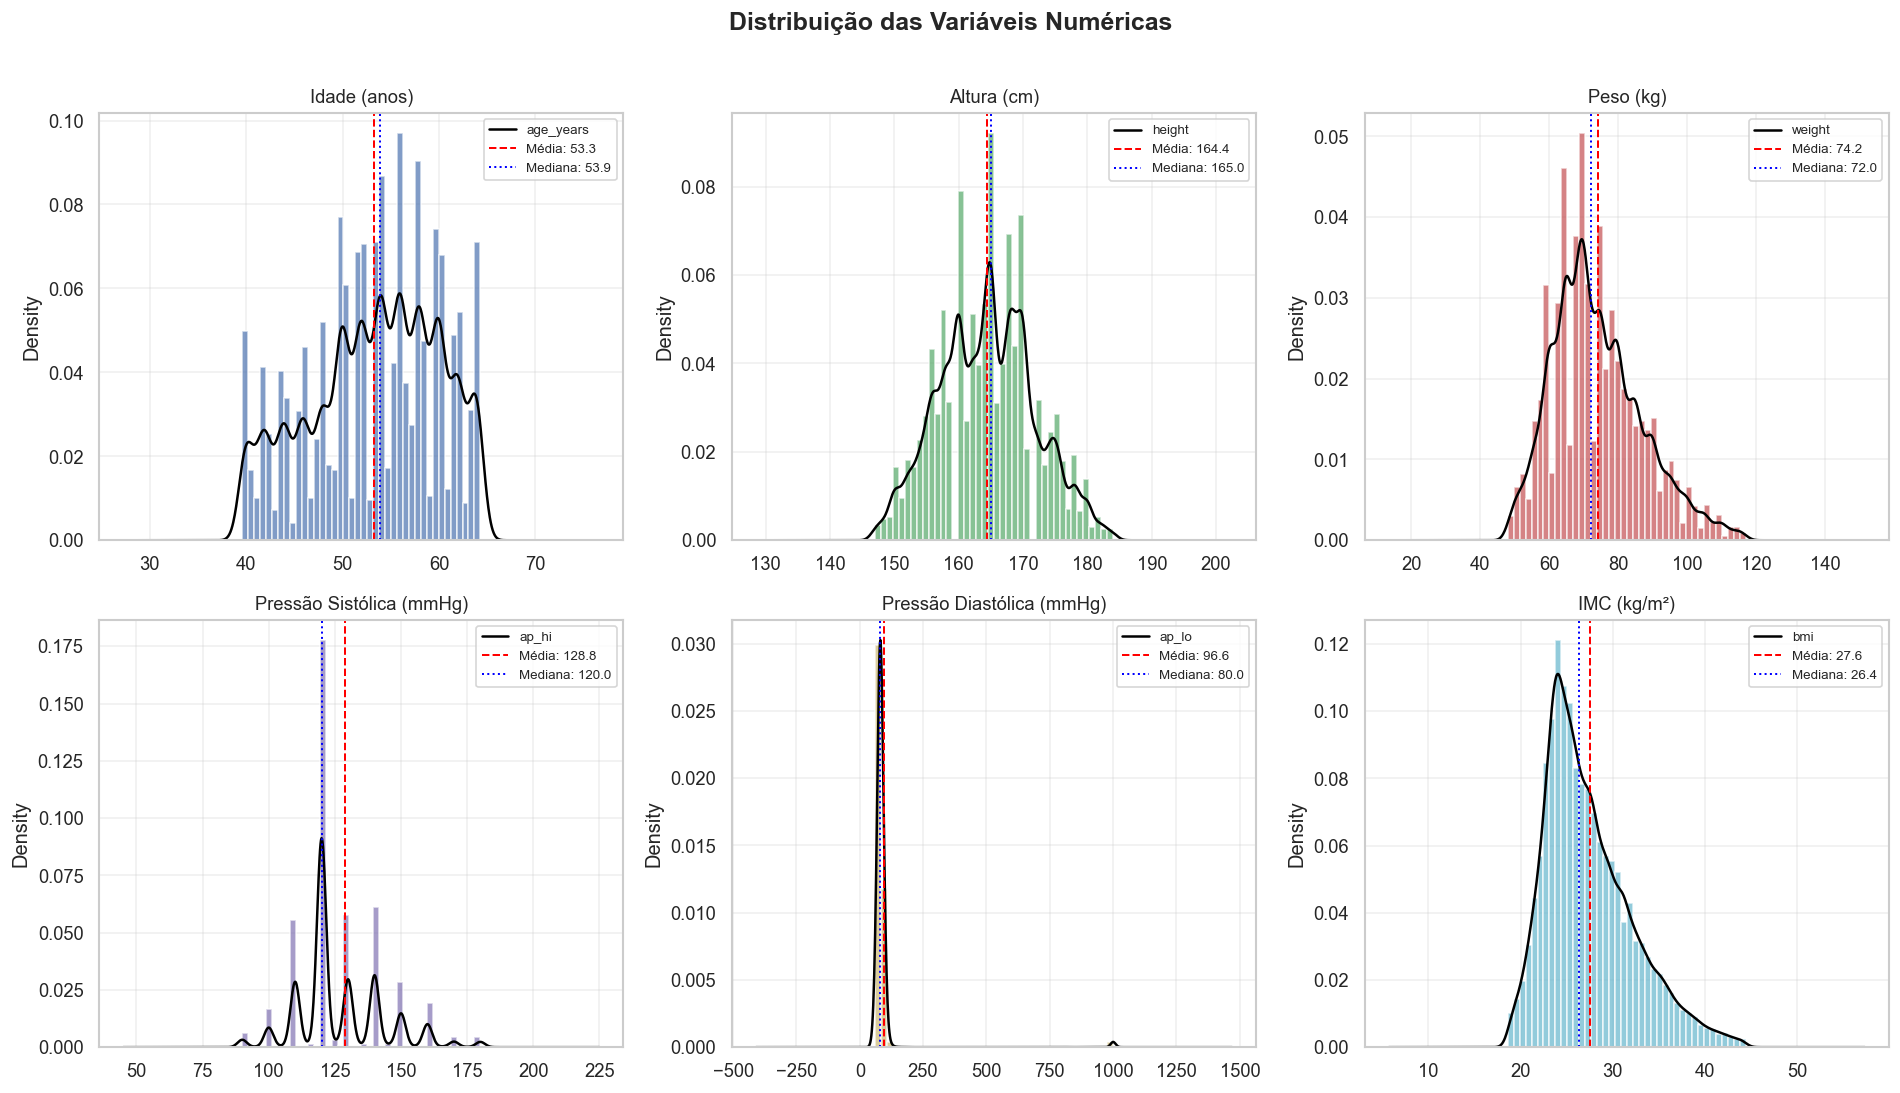

In [8]:
# Histogramas + KDE das variáveis numéricas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)

variaveis = [
    ('age_years', 'Idade (anos)', '#4C72B0'),
    ('height', 'Altura (cm)', '#55A868'),
    ('weight', 'Peso (kg)', '#C44E52'),
    ('ap_hi', 'Pressão Sistólica (mmHg)', '#8172B2'),
    ('ap_lo', 'Pressão Diastólica (mmHg)', '#CCB974'),
    ('bmi', 'IMC (kg/m²)', '#64B5CD'),
]

for ax, (col, titulo, cor) in zip(axes.flatten(), variaveis):
    dados = df_plot[col].dropna()
    # Limitar outliers extremos apenas para visualização
    q1, q3 = dados.quantile(0.01), dados.quantile(0.99)
    dados_viz = dados[(dados >= q1) & (dados <= q3)]
    ax.hist(dados_viz, bins=40, color=cor, alpha=0.7, edgecolor='white', density=True)
    dados_viz.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.axvline(dados.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Média: {dados.mean():.1f}')
    ax.axvline(dados.median(), color='blue', linestyle=':', linewidth=1.2, label=f'Mediana: {dados.median():.1f}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Box Plots por Presença de Doença

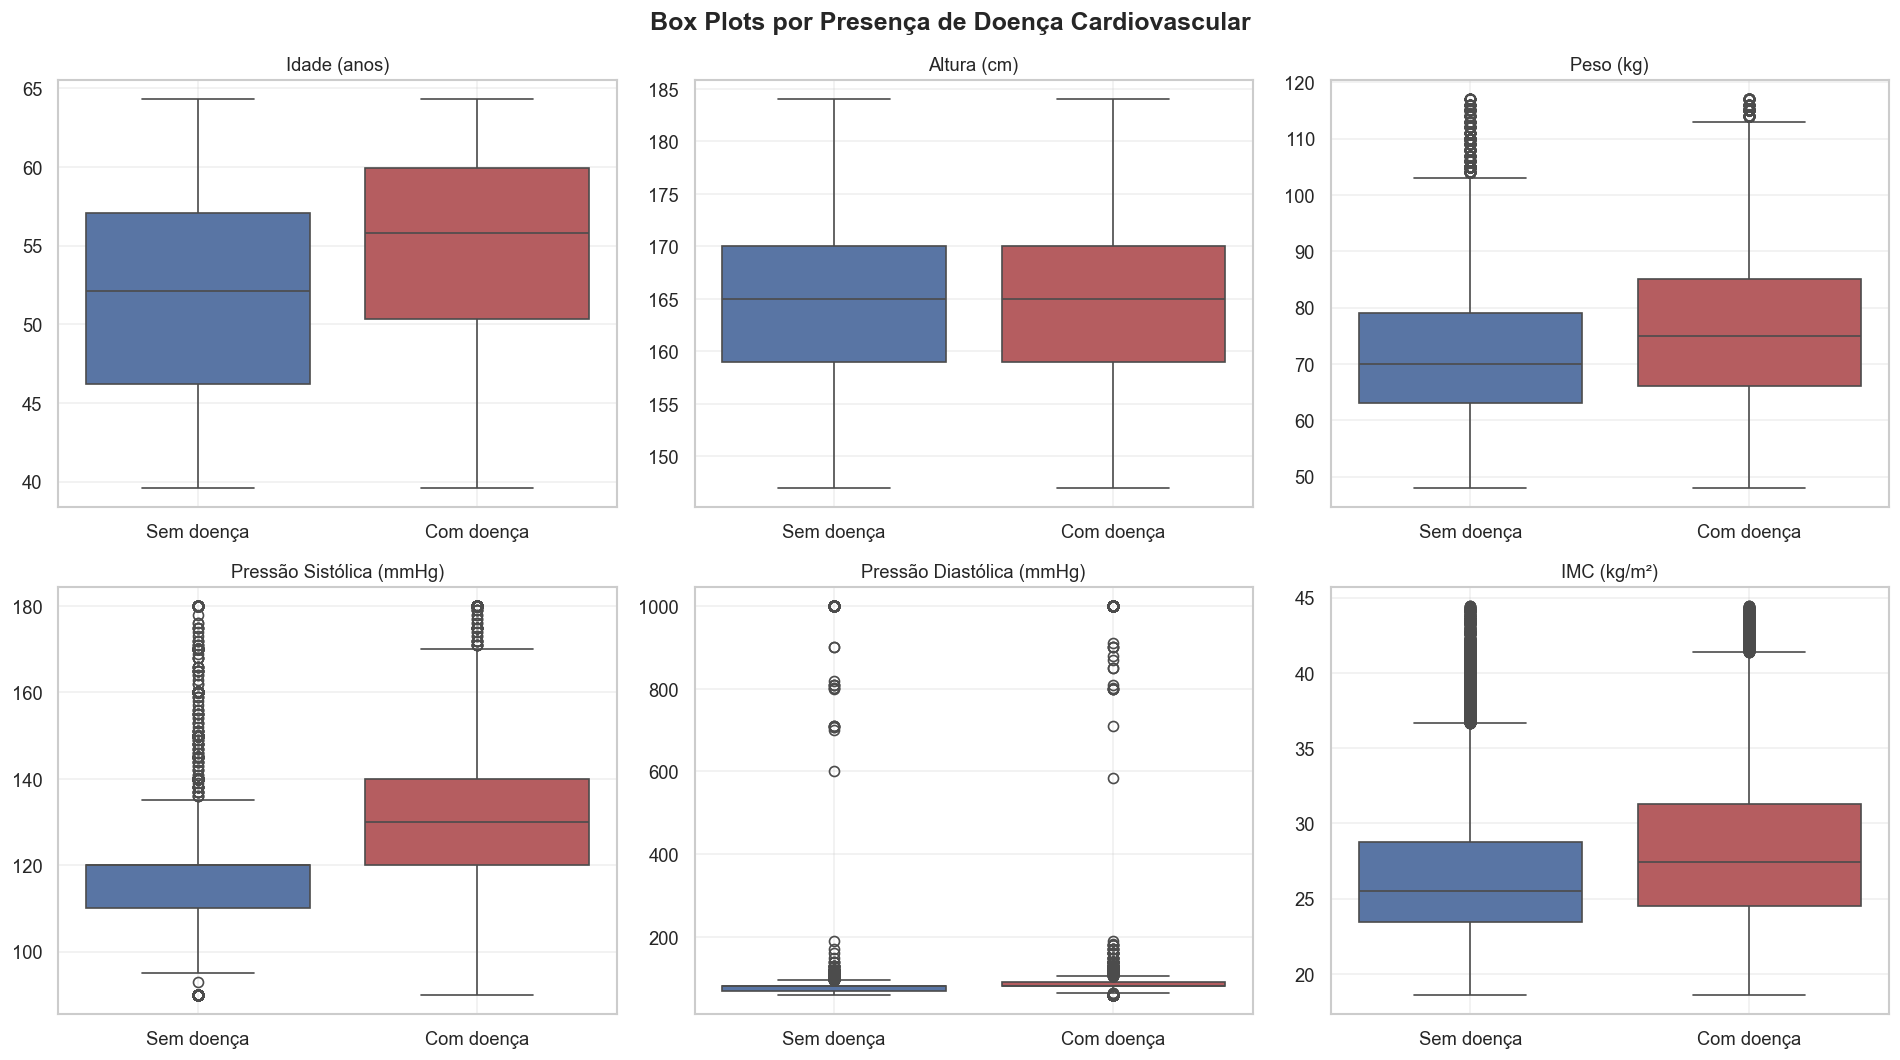

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Box Plots por Presença de Doença Cardiovascular', fontsize=15, fontweight='bold')

palette = {'Sem doença': '#4C72B0', 'Com doença': '#C44E52'}

for ax, (col, titulo, _) in zip(axes.flatten(), variaveis):
    dados_bp = df_plot[[col, 'cardio_label']].copy().dropna()
    # Limitar outliers extremos apenas para visualização
    q1, q3 = dados_bp[col].quantile(0.01), dados_bp[col].quantile(0.99)
    dados_bp = dados_bp[(dados_bp[col] >= q1) & (dados_bp[col] <= q3)]
    sns.boxplot(data=dados_bp, x='cardio_label', y=col, palette=palette, ax=ax,
                order=['Sem doença', 'Com doença'])
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Distribuição da Variável Alvo

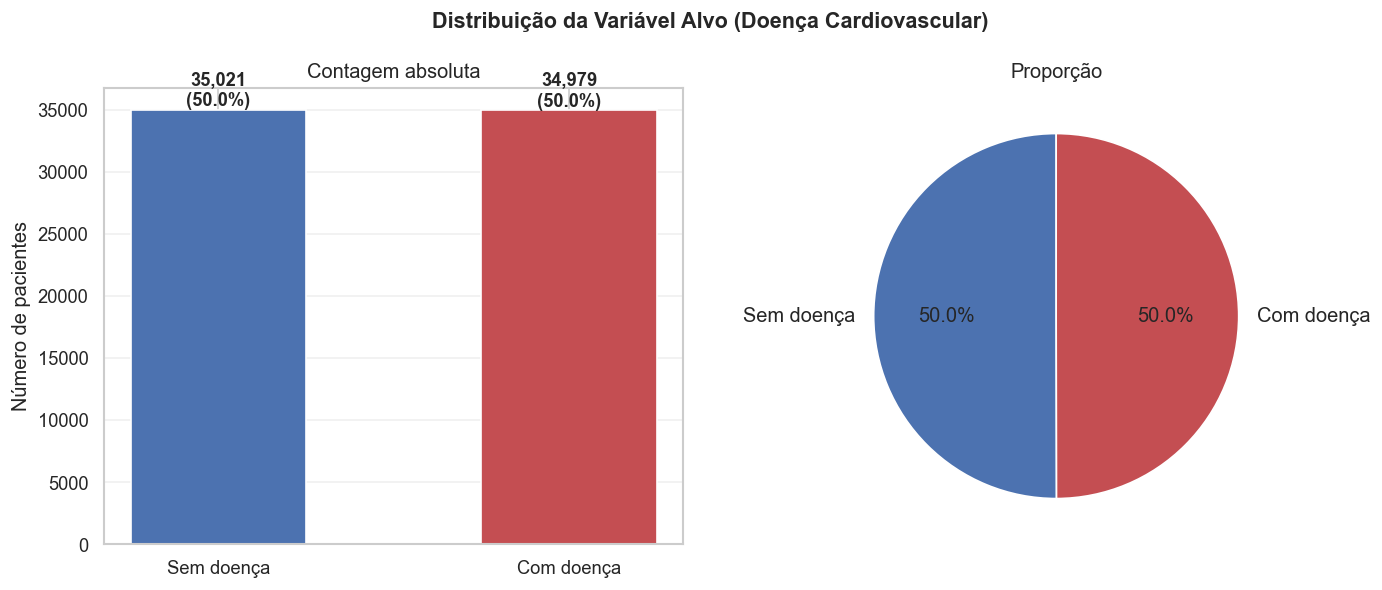

Dataset balanceado: True


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribuição da Variável Alvo (Doença Cardiovascular)', fontsize=13, fontweight='bold')

contagens = df_plot['cardio_label'].value_counts()
cores = ['#4C72B0', '#C44E52']

axes[0].bar(contagens.index, contagens.values, color=cores, edgecolor='white', width=0.5)
for i, (val, cnt) in enumerate(zip(contagens.index, contagens.values)):
    axes[0].text(i, cnt + 300, f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem absoluta')
axes[0].set_ylabel('Número de pacientes')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie(contagens.values, labels=contagens.index, colors=cores,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção')

plt.tight_layout()
plt.show()

print(f"Dataset balanceado: {abs(contagens.values[0] - contagens.values[1]) < 100}")

## 9. Variáveis Categóricas por Doença

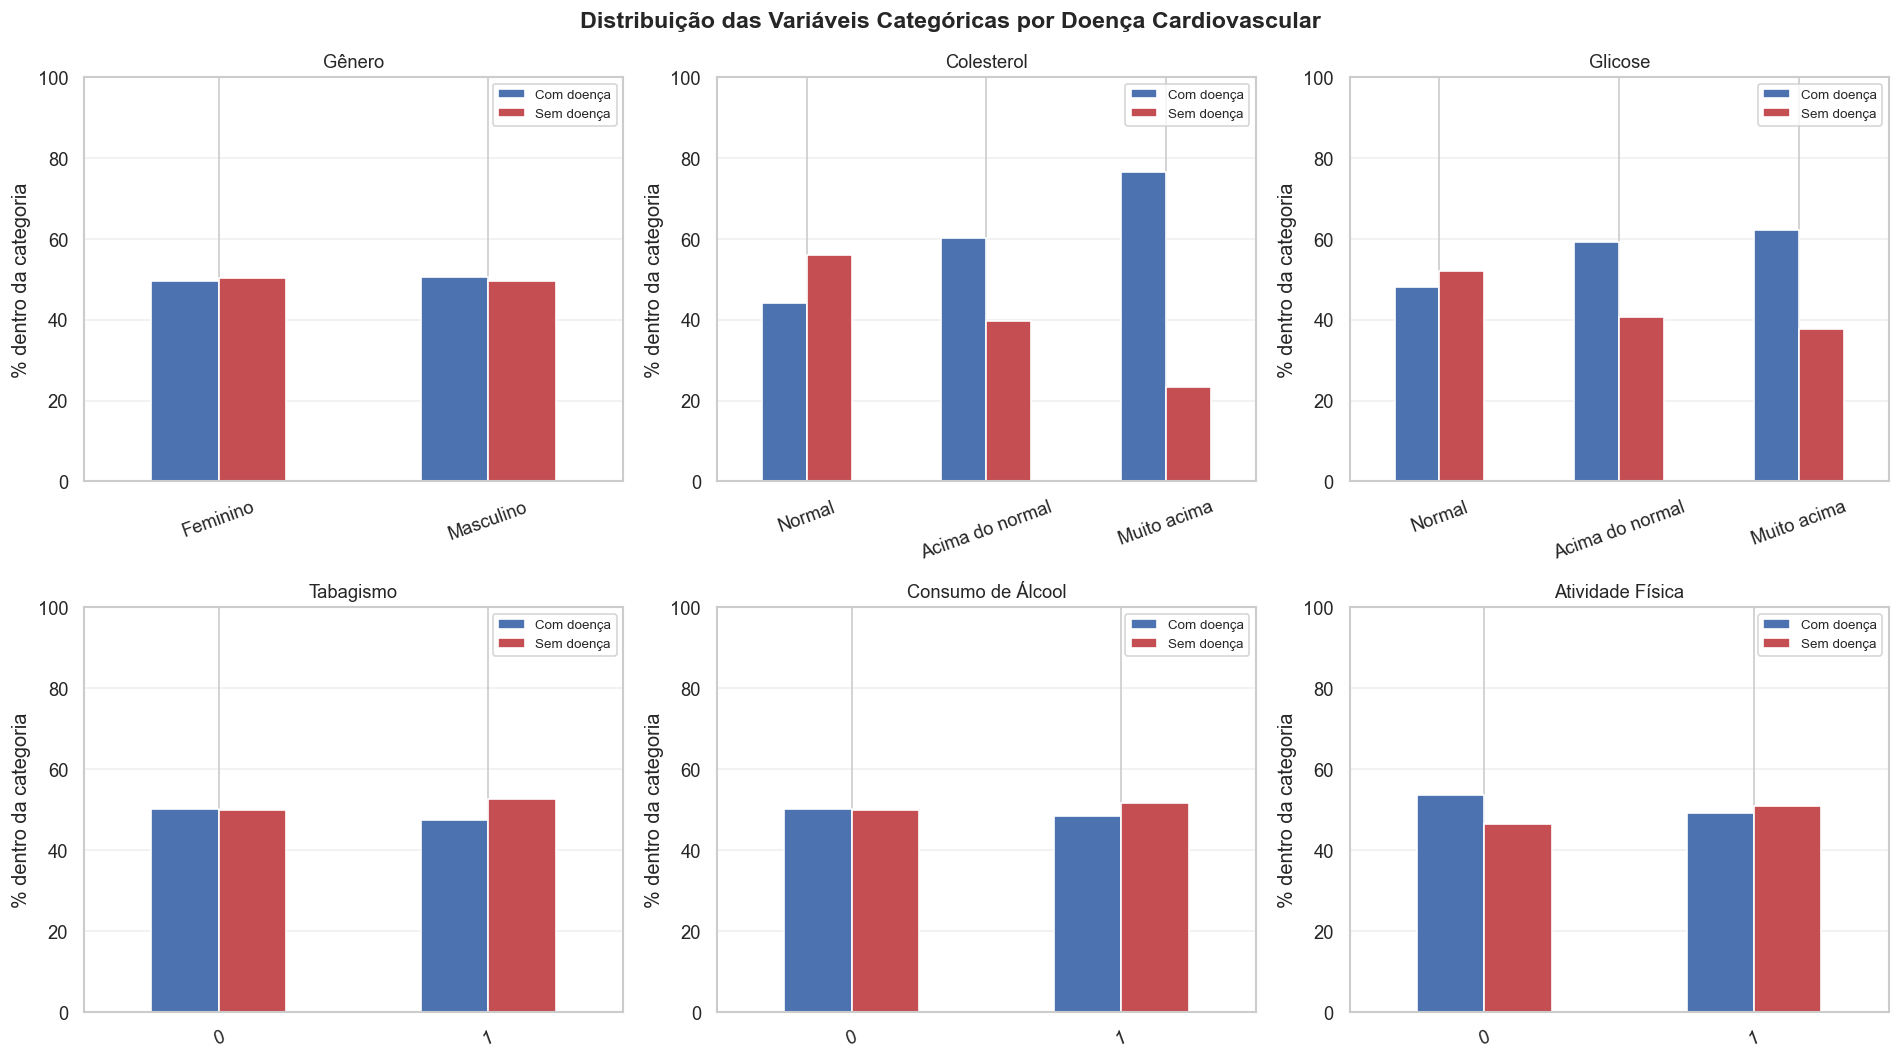

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribuição das Variáveis Categóricas por Doença Cardiovascular',
             fontsize=14, fontweight='bold')

cat_plot = [
    ('gender_label', 'Gênero', None),
    ('cholesterol_label', 'Colesterol', ['Normal', 'Acima do normal', 'Muito acima']),
    ('gluc_label', 'Glicose', ['Normal', 'Acima do normal', 'Muito acima']),
    ('smoke', 'Tabagismo', None),
    ('alco', 'Consumo de Álcool', None),
    ('active', 'Atividade Física', None),
]

for ax, (col, titulo, ordem) in zip(axes.flatten(), cat_plot):
    if ordem:
        ct = pd.crosstab(df_plot[col], df_plot['cardio_label'])
        ct = ct.reindex(ordem)
    else:
        ct = pd.crosstab(df_plot[col], df_plot['cardio_label'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'],
                edgecolor='white', rot=20)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('% dentro da categoria')
    ax.legend(title='', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 10. Análise de Correlação

In [12]:
# Variáveis numéricas para correlação
num_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'cardio']
labels_corr = ['Idade', 'Altura', 'Peso', 'P. Sistólica', 'P. Diastólica',
               'Colesterol', 'Glicose', 'Tabagismo', 'Álcool',
               'Ativ. Física', 'IMC', 'Doença Card.']

corr_matrix = df_plot[num_cols].corr(method='pearson')
corr_matrix.index = labels_corr
corr_matrix.columns = labels_corr

# Correlações com a variável alvo
corr_com_alvo = corr_matrix['Doença Card.'].drop('Doença Card.').sort_values(ascending=False)

print("CORRELAÇÃO DE PEARSON COM A VARIÁVEL ALVO (cardio):\n")
for var, val in corr_com_alvo.items():
    barra = '█' * int(abs(val) * 30)
    sinal = '+' if val > 0 else '-'
    print(f"{var:20s}: {sinal}{abs(val):.4f}  {barra}")

CORRELAÇÃO DE PEARSON COM A VARIÁVEL ALVO (cardio):

Idade               : +0.2381  ███████
Colesterol          : +0.2211  ██████
Peso                : +0.1817  █████
IMC                 : +0.1656  ████
Glicose             : +0.0893  ██
P. Diastólica       : +0.0657  █
P. Sistólica        : +0.0545  █
Álcool              : -0.0073  
Altura              : -0.0108  
Tabagismo           : -0.0155  
Ativ. Física        : -0.0357  █


## 11. Heatmap de Correlação

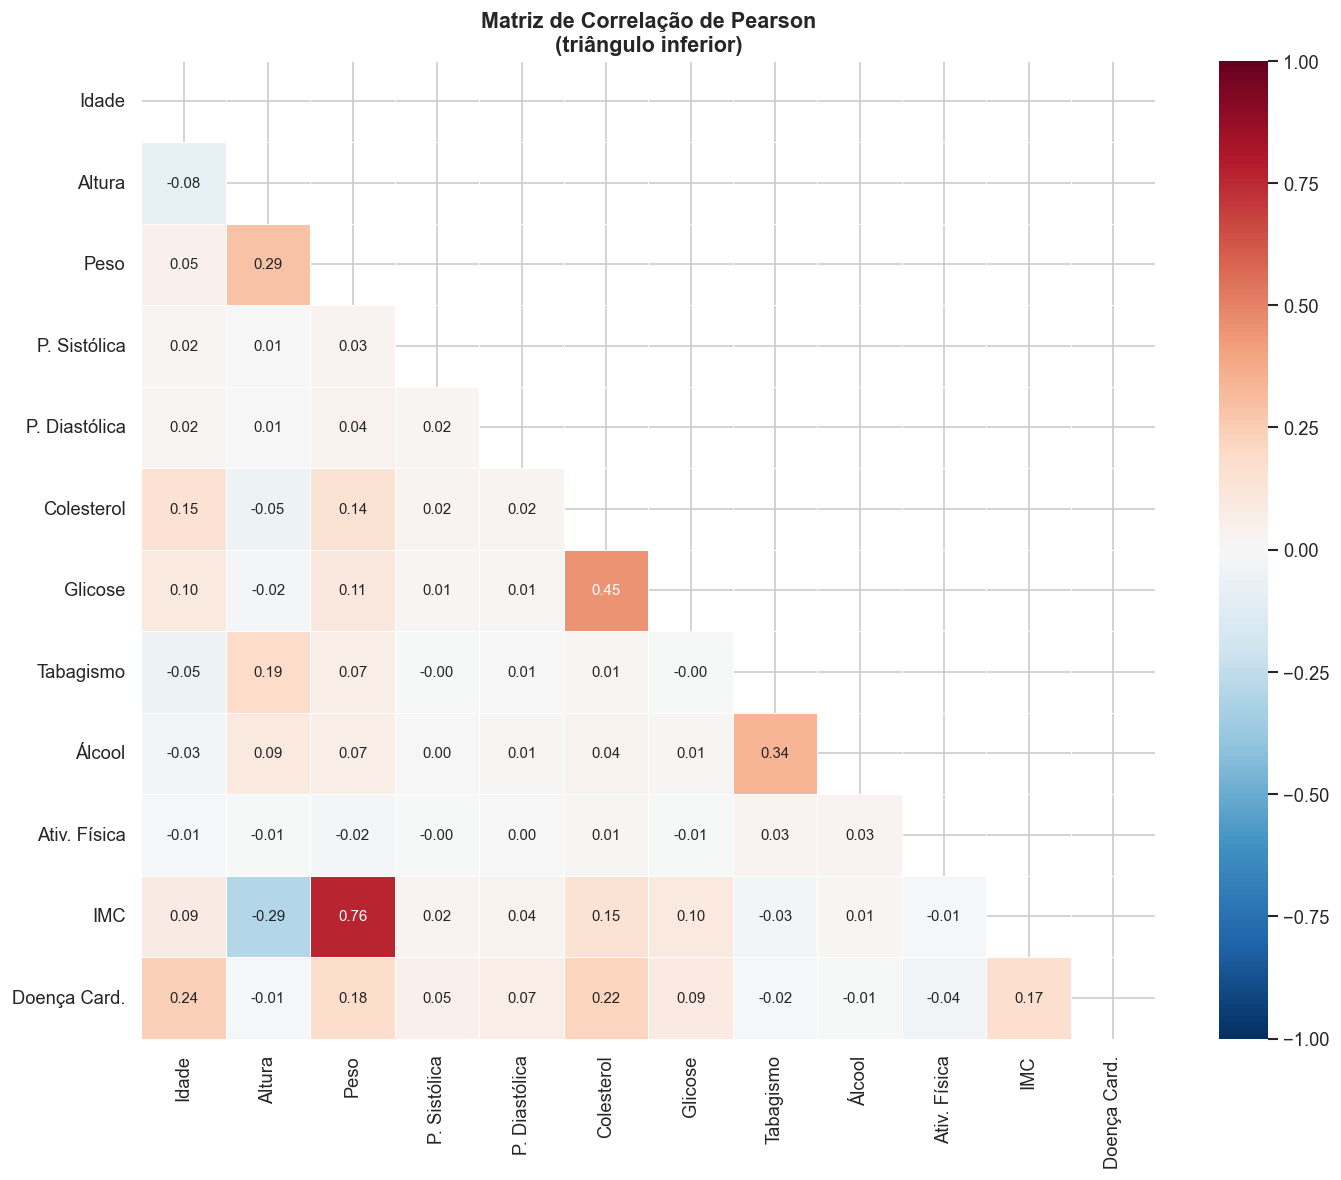

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Matriz de Correlação de Pearson\n(triângulo inferior)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Correlação com o Alvo (Barras)

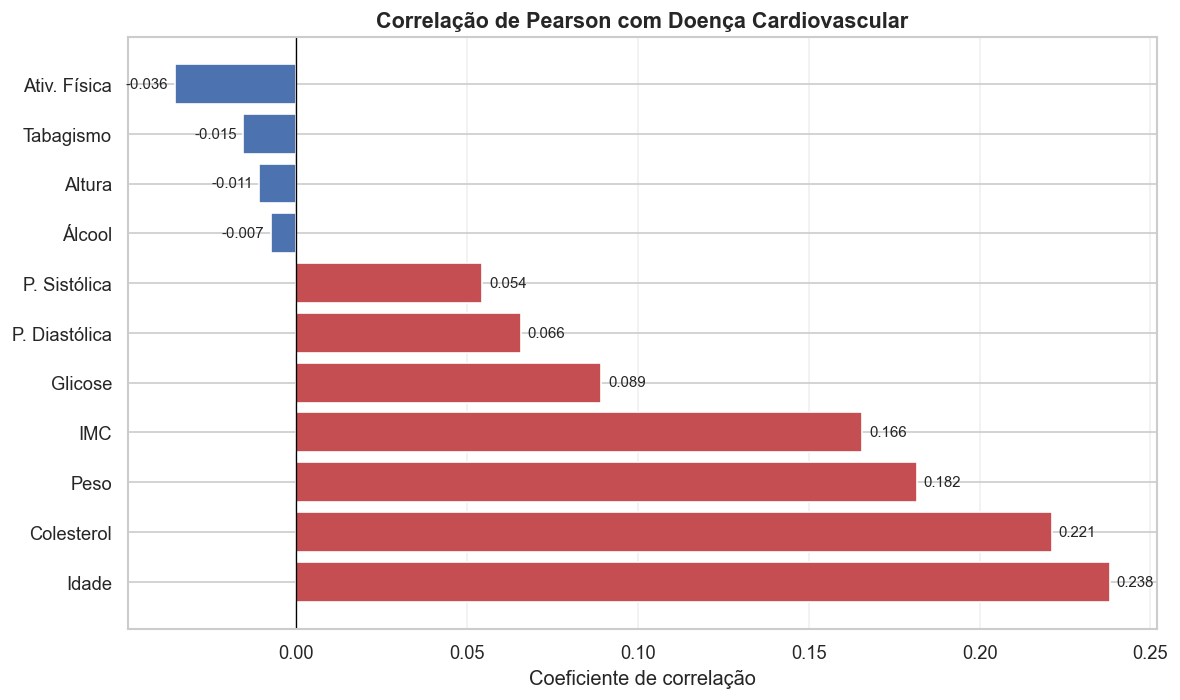

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
cores_corr = ['#C44E52' if v > 0 else '#4C72B0' for v in corr_com_alvo.values]
ax.barh(corr_com_alvo.index, corr_com_alvo.values, color=cores_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson com Doença Cardiovascular', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de correlação')
ax.grid(True, alpha=0.3, axis='x')
for i, val in enumerate(corr_com_alvo.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 13. Identificação de Outliers e Inconsistências

In [15]:
print("ANÁLISE DE OUTLIERS (método IQR):\n")
outlier_resumo = {}
for col, nome in [('age_years', 'Idade (anos)'), ('height', 'Altura'),
                   ('weight', 'Peso'), ('ap_hi', 'Pressão Sistólica'),
                   ('ap_lo', 'Pressão Diastólica'), ('bmi', 'IMC')]:
    Q1 = df_plot[col].quantile(0.25)
    Q3 = df_plot[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_plot[(df_plot[col] < lower) | (df_plot[col] > upper)]
    pct = len(outliers) / len(df) * 100
    outlier_resumo[nome] = {'N outliers': len(outliers), '% outliers': round(pct, 2),
                             'Limite inferior': round(lower, 1), 'Limite superior': round(upper, 1),
                             'Min real': round(df_plot[col].min(), 1), 'Max real': round(df_plot[col].max(), 1)}
    print(f"{nome:25s}: {len(outliers):5,} outliers ({pct:.2f}%)  |  "
          f"Limite [{lower:.1f}, {upper:.1f}]  |  Real [{df_plot[col].min():.1f}, {df_plot[col].max():.1f}]")

ANÁLISE DE OUTLIERS (método IQR):

Idade (anos)             :     4 outliers (0.01%)  |  Limite [33.4, 73.4]  |  Real [29.6, 64.9]
Altura                   :   519 outliers (0.74%)  |  Limite [142.5, 186.5]  |  Real [55.0, 250.0]
Peso                     : 1,819 outliers (2.60%)  |  Limite [39.5, 107.5]  |  Real [10.0, 200.0]
Pressão Sistólica        : 1,435 outliers (2.05%)  |  Limite [90.0, 170.0]  |  Real [-150.0, 16020.0]
Pressão Diastólica       : 4,632 outliers (6.62%)  |  Limite [65.0, 105.0]  |  Real [-70.0, 11000.0]
IMC                      : 2,000 outliers (2.86%)  |  Limite [14.4, 39.7]  |  Real [3.5, 298.7]


In [16]:
print("\nVALORES CLINICAMENTE INVÁLIDOS (pressão arterial):\n")
invalidos_ap_hi = df[(df['ap_hi'] <= 0) | (df['ap_hi'] > 300)]
invalidos_ap_lo = df[(df['ap_lo'] <= 0) | (df['ap_lo'] > 200)]
invalidos_ap_neg = df[df['ap_hi'] < df['ap_lo']]

print(f"Pressão sistólica ≤ 0 ou > 300 mmHg : {len(invalidos_ap_hi):,} registros")
print(f"Pressão diastólica ≤ 0 ou > 200 mmHg: {len(invalidos_ap_lo):,} registros")
print(f"Sistólica < Diastólica (impossível)  : {len(invalidos_ap_neg):,} registros")

invalidos_height = df[(df['height'] < 100) | (df['height'] > 220)]
invalidos_weight = df[(df['weight'] < 30) | (df['weight'] > 200)]
print(f"Altura < 100 cm ou > 220 cm          : {len(invalidos_height):,} registros")
print(f"Peso < 30 kg ou > 200 kg             : {len(invalidos_weight):,} registros")

total_invalidos = len(
    df[(df['ap_hi'] <= 0) | (df['ap_hi'] > 300) |
       (df['ap_lo'] <= 0) | (df['ap_lo'] > 200) |
       (df['ap_hi'] < df['ap_lo']) |
       (df['height'] < 100) | (df['height'] > 220) |
       (df['weight'] < 30) | (df['weight'] > 200)]
)
print(f"\nTotal de registros com ao menos 1 valor inválido: {total_invalidos:,} "
      f"({total_invalidos/len(df)*100:.2f}%)")


VALORES CLINICAMENTE INVÁLIDOS (pressão arterial):

Pressão sistólica ≤ 0 ou > 300 mmHg : 47 registros
Pressão diastólica ≤ 0 ou > 200 mmHg: 975 registros
Sistólica < Diastólica (impossível)  : 1,234 registros
Altura < 100 cm ou > 220 cm          : 30 registros
Peso < 30 kg ou > 200 kg             : 7 registros

Total de registros com ao menos 1 valor inválido: 1,323 (1.89%)


## 14. Scatter Pressão Arterial (Inválidos Destacados)

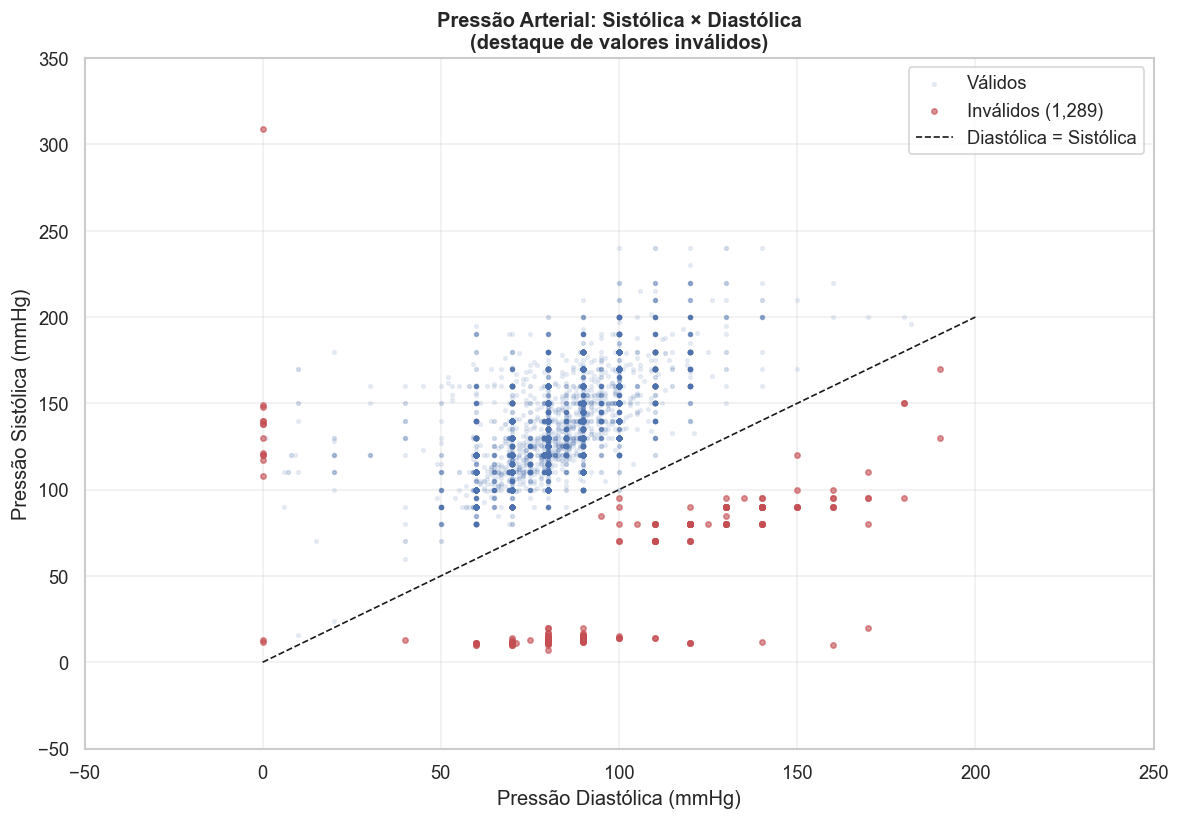

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
validos = df[(df['ap_hi'] > 0) & (df['ap_hi'] <= 300) &
             (df['ap_lo'] > 0) & (df['ap_lo'] <= 200) &
             (df['ap_hi'] >= df['ap_lo'])]
inval = df[~df.index.isin(validos.index)]

ax.scatter(validos['ap_lo'], validos['ap_hi'], alpha=0.1, s=5, color='#4C72B0', label='Válidos')
ax.scatter(inval['ap_lo'], inval['ap_hi'], alpha=0.6, s=10, color='#C44E52', label=f'Inválidos ({len(inval):,})')
ax.plot([0, 200], [0, 200], 'k--', linewidth=1, label='Diastólica = Sistólica')
ax.set_xlabel('Pressão Diastólica (mmHg)')
ax.set_ylabel('Pressão Sistólica (mmHg)')
ax.set_title('Pressão Arterial: Sistólica × Diastólica\n(destaque de valores inválidos)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-50, 250)
ax.set_ylim(-50, 350)
plt.tight_layout()
plt.show()

## 15. Distribuição de Idade por Doença

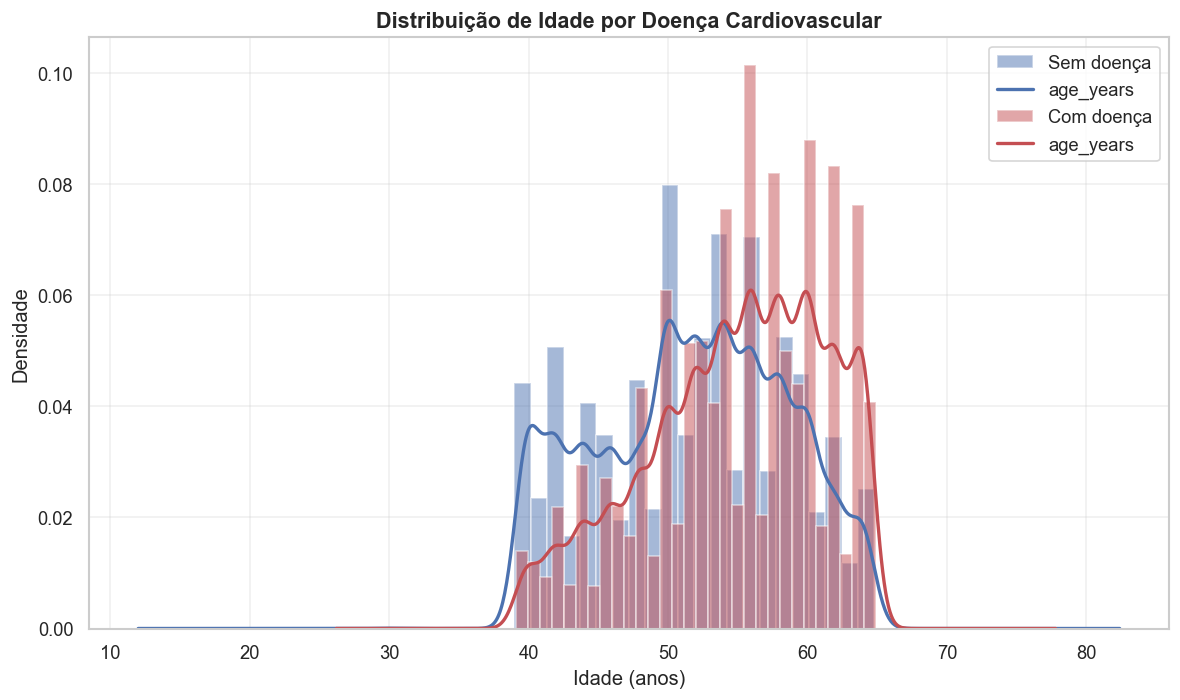

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, cor in [('Sem doença', '#4C72B0'), ('Com doença', '#C44E52')]:
    dados = df_plot[df_plot['cardio_label'] == label]['age_years']
    ax.hist(dados, bins=30, alpha=0.5, color=cor, label=label,
            density=True, edgecolor='white')
    dados.plot.kde(ax=ax, color=cor, linewidth=2)
ax.set_title('Distribuição de Idade por Doença Cardiovascular', fontsize=13, fontweight='bold')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Densidade')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Prevalência por Faixa Etária

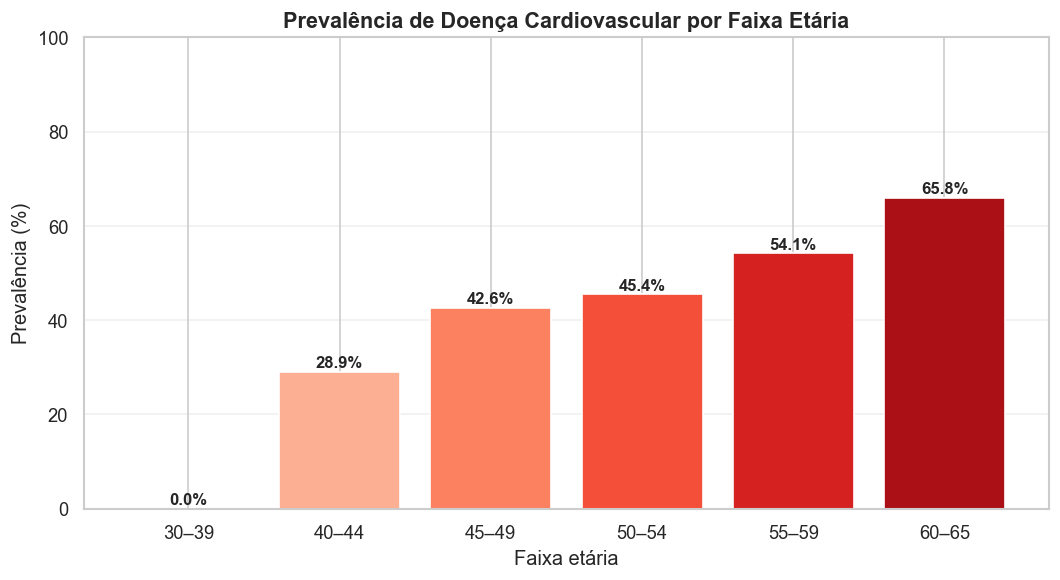

In [19]:
df_plot['faixa_etaria'] = pd.cut(df_plot['age_years'],
    bins=[29, 39, 44, 49, 54, 59, 65],
    labels=['30–39', '40–44', '45–49', '50–54', '55–59', '60–65'])

prev_faixa = df_plot.groupby('faixa_etaria', observed=True)['cardio'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(prev_faixa.index.astype(str), prev_faixa.values,
              color=sns.color_palette("Reds", len(prev_faixa)), edgecolor='white')
ax.set_title('Prevalência de Doença Cardiovascular por Faixa Etária', fontsize=13, fontweight='bold')
ax.set_xlabel('Faixa etária')
ax.set_ylabel('Prevalência (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, prev_faixa.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 17. Pairplot - Variáveis Principais

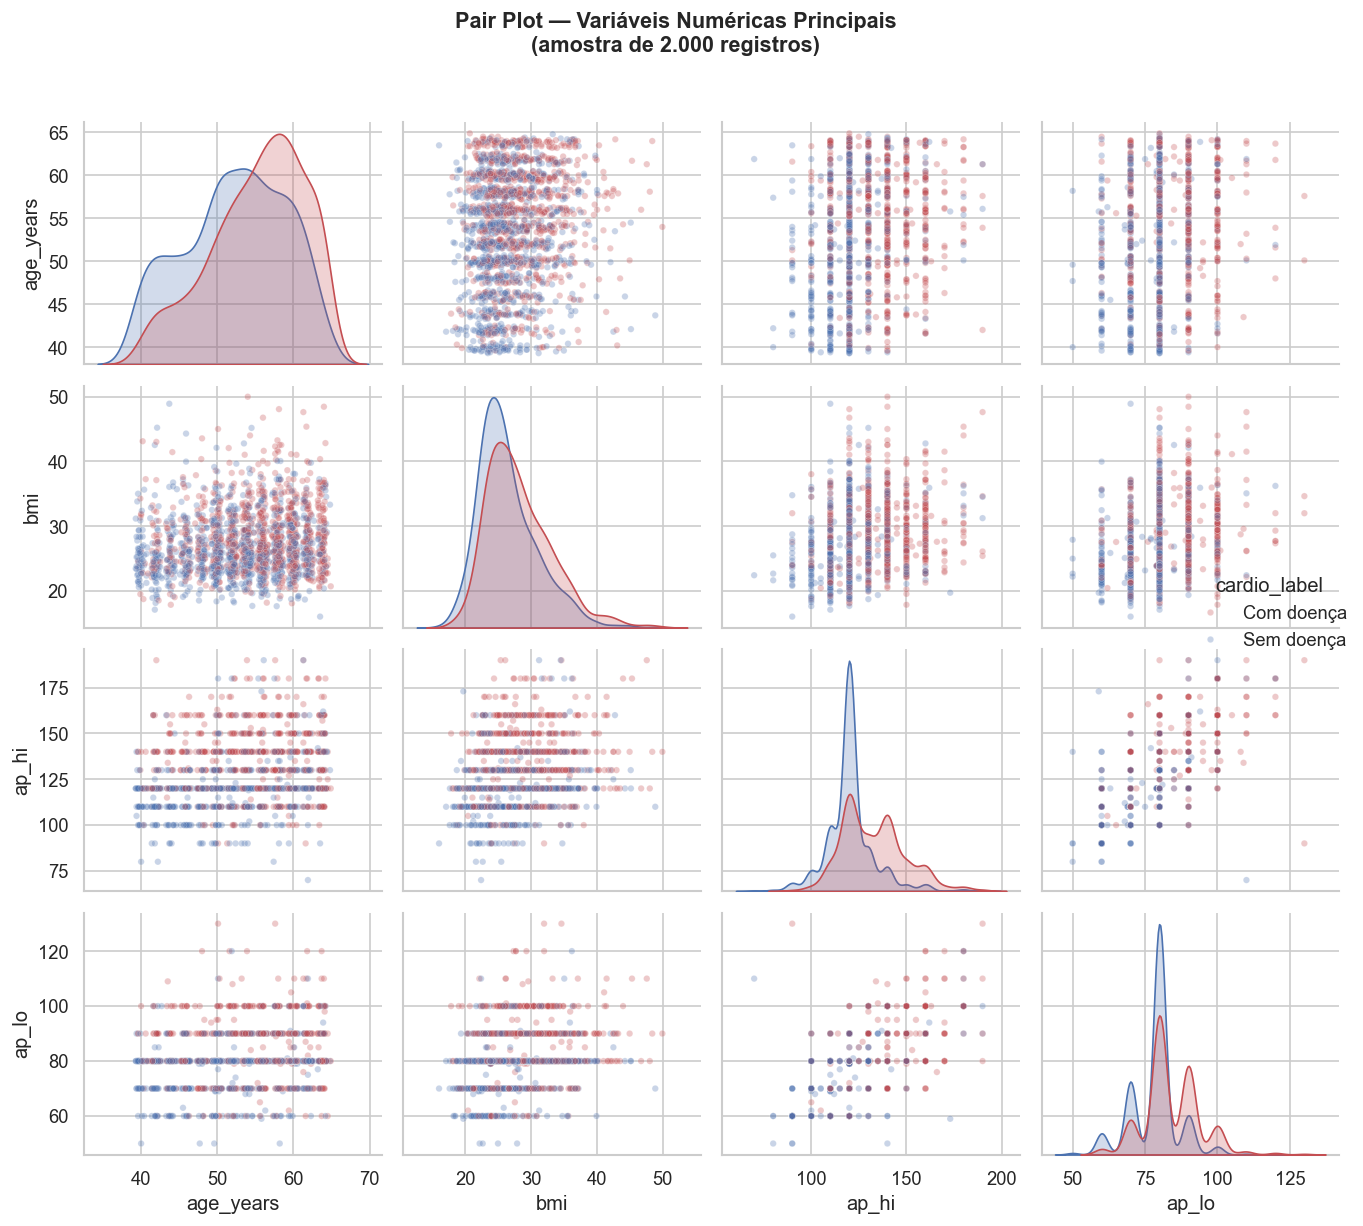

In [24]:
# Pair plot das principais variáveis numéricas (amostra de 2000 para performance)
sample = df_plot[['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cardio_label']].dropna()
sample = sample[(sample['ap_hi'] > 60) & (sample['ap_hi'] < 200) &
                (sample['ap_lo'] > 40) & (sample['ap_lo'] < 150) &
                (sample['bmi'] > 15) & (sample['bmi'] < 50)].sample(2000, random_state=42)

g = sns.pairplot(sample, hue='cardio_label', palette={'Sem doença': '#4C72B0', 'Com doença': '#C44E52'},
                 plot_kws={'alpha': 0.3, 's': 15},
                 vars=['age_years', 'bmi', 'ap_hi', 'ap_lo'],
                 diag_kind='kde')
g.fig.suptitle('Pair Plot — Variáveis Numéricas Principais\n(amostra de 2.000 registros)',
               y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 18. Resumo Final dos Achados

In [22]:
print("="*65)
print("  RESUMO DOS ACHADOS DA EDA")
print("="*65)

print(f"""
  DATASET
  ├── Total de registros : {len(df):,}
  ├── Total de atributos : {df.shape[1]}
  ├── Valores nulos      : {df.isnull().sum().sum()} (dataset completo)
  └── Duplicatas         : {df.duplicated().sum()}

  VARIÁVEL ALVO
  ├── Sem doença cardiovascular : {(df['cardio']==0).sum():,} ({(df['cardio']==0).mean()*100:.1f}%)
  └── Com doença cardiovascular : {(df['cardio']==1).sum():,} ({(df['cardio']==1).mean()*100:.1f}%)
  → Dataset razoavelmente balanceado ✓

  PERFIL DOS PACIENTES
  ├── Idade média         : {df_plot['age_years'].mean():.1f} anos
  │   (mín: {df_plot['age_years'].min():.0f} | máx: {df_plot['age_years'].max():.0f})
  ├── IMC médio           : {df_plot['bmi'].mean():.1f} kg/m²
  ├── Pressão sistólica   : média {df['ap_hi'].mean():.0f} mmHg
  └── Pressão diastólica  : média {df['ap_lo'].mean():.0f} mmHg

  VARIÁVEIS MAIS CORRELACIONADAS COM DOENÇA (Pearson):
""")
for var, val in corr_com_alvo.head(5).items():
    print(f"    {var:22s}: {val:+.4f}")

print(f"""
  QUALIDADE DOS DADOS
  └── Registros com valores clinicamente inválidos: {total_invalidos:,}
      ({total_invalidos/len(df)*100:.2f}% do total)
      → Serão tratados na Etapa de Engenharia de Dados

  PRINCIPAIS VISUALIZAÇÕES GERADAS
  ├── Distribuições das variáveis numéricas (histogramas + KDE)
  ├── Box plots por presença de doença
  ├── Distribuição balanceada da variável alvo
  ├── Variáveis categóricas por status da doença
  ├── Matriz de correlação de Pearson
  ├── Identificação de outliers e inconsistências clínicas
  ├── Distribuição etária e prevalência por faixa
  └── Pairplot das principais variáveis numéricas
""")
print("="*65)
print("  EDA concluída com sucesso! ")
print("="*65)

  RESUMO DOS ACHADOS DA EDA

  DATASET
  ├── Total de registros : 70,000
  ├── Total de atributos : 13
  ├── Valores nulos      : 0 (dataset completo)
  └── Duplicatas         : 0

  VARIÁVEL ALVO
  ├── Sem doença cardiovascular : 35,021 (50.0%)
  └── Com doença cardiovascular : 34,979 (50.0%)
  → Dataset razoavelmente balanceado ✓

  PERFIL DOS PACIENTES
  ├── Idade média         : 53.3 anos
  │   (mín: 30 | máx: 65)
  ├── IMC médio           : 27.6 kg/m²
  ├── Pressão sistólica   : média 129 mmHg
  └── Pressão diastólica  : média 97 mmHg

  VARIÁVEIS MAIS CORRELACIONADAS COM DOENÇA (Pearson):

    Idade                 : +0.2381
    Colesterol            : +0.2211
    Peso                  : +0.1817
    IMC                   : +0.1656
    Glicose               : +0.0893

  QUALIDADE DOS DADOS
  └── Registros com valores clinicamente inválidos: 1,323
      (1.89% do total)
      → Serão tratados na Etapa de Engenharia de Dados

  PRINCIPAIS VISUALIZAÇÕES GERADAS
  ├── Distribuições da